In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

notebook_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.insert(0, project_root)

from template.prelude_template import load_polymarket_data, load_data
from EDA import *
btc = load_data()

2026-02-21 17:24:38 INFO     Loading CoinMetrics BTC data from local file: /home/jason/bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv
2026-02-21 17:24:38 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-02-21 17:24:38 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


In [2]:
# get gold price and dollar index data
gold = pd.read_csv(f'{project_root}/data/yfinance/GC_F.csv')
dollar = pd.read_csv(f'{project_root}/data/yfinance/DX-Y.NYB.csv')

gold["Date"] = pd.to_datetime(gold["Date"])
dollar["Date"] = pd.to_datetime(dollar["Date"])

gold.set_index("Date", inplace=True)
dollar.set_index("Date", inplace=True)

In [3]:
# merge dataframe
btc_merge = pd.merge(left=btc, right=gold["Close"], how='left', left_index=True, right_index=True)
btc_merge.rename(columns={"Close":"Gold"},inplace=True)
btc_merge = pd.merge(left=btc_merge, right=dollar["Close"], how='left', left_index=True, right_index=True)
btc_merge.rename(columns={"Close":"Dollar"}, inplace=True)
btc_merge[["Gold", "Dollar"]] = btc_merge[["Gold", "Dollar"]].ffill()

### 1. Explore DATA ANALYSIS - BTC_MERGE 

#### 1.1 Original Time Series with One Day Differentiation

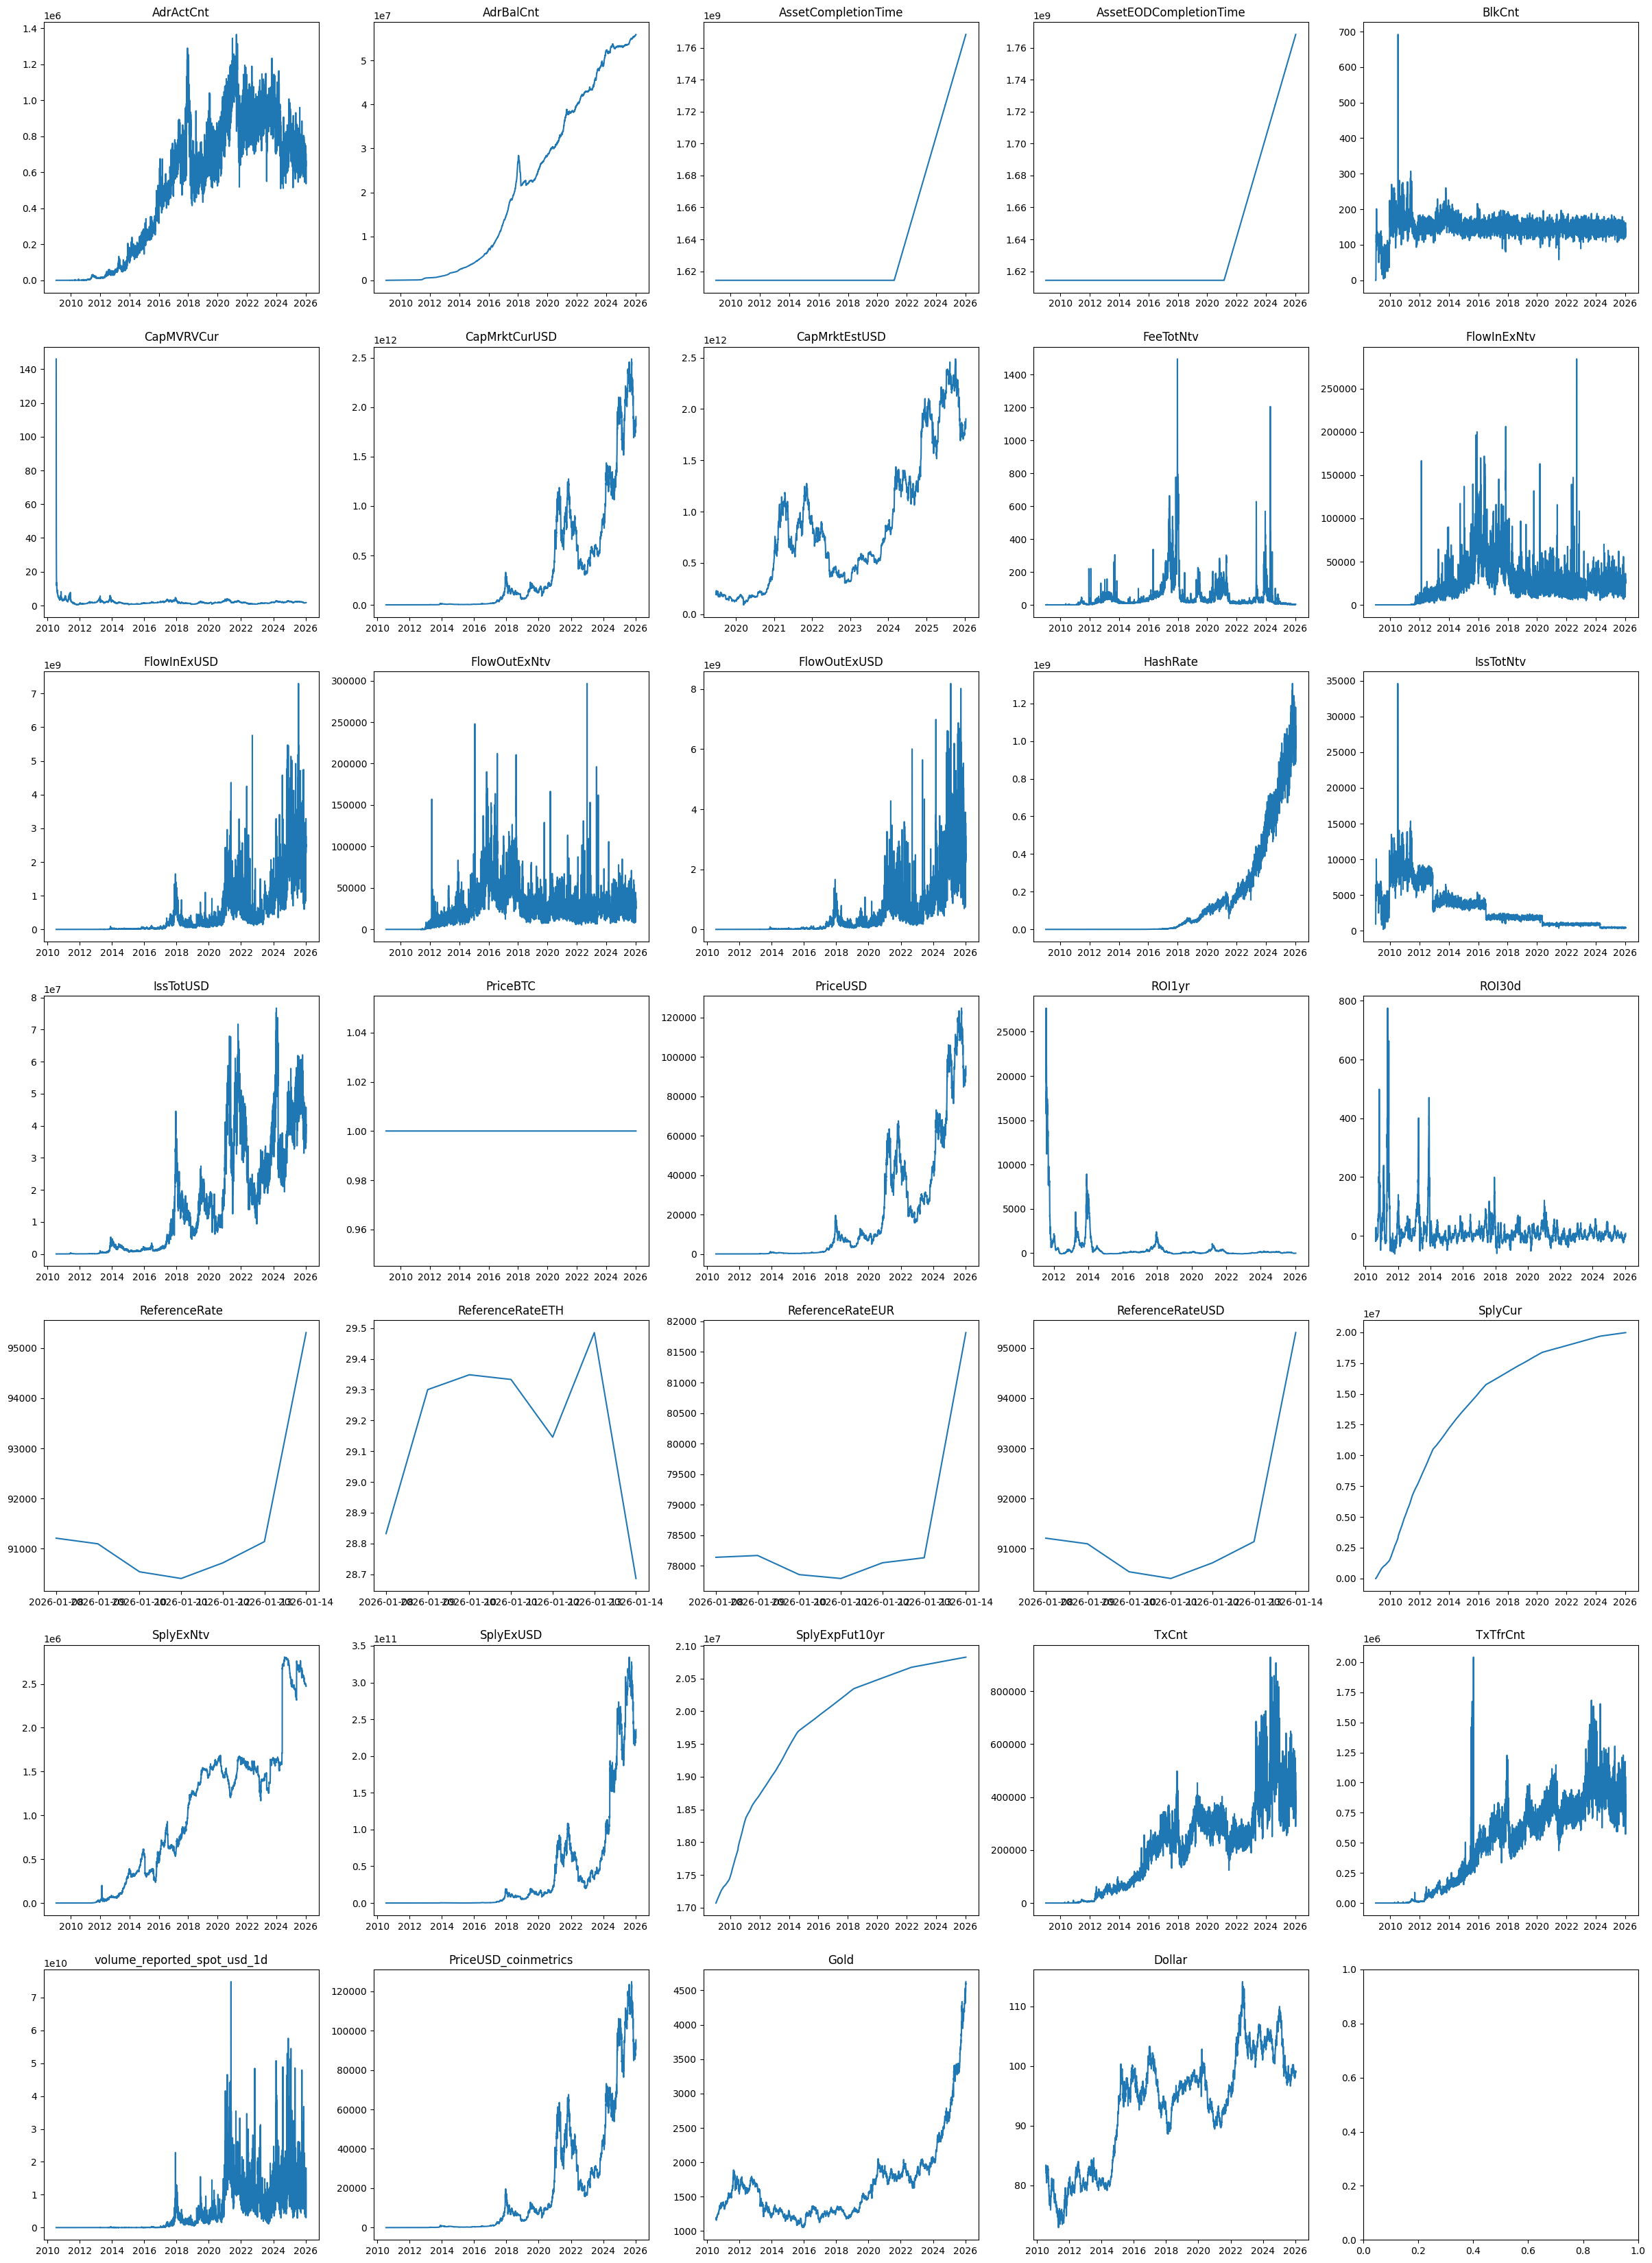

In [4]:
# plot original time series

original_ts_plot = plot_ts(btc_merge)

## from plots we would say that these columns are not informative: 
#       AssetCompltionTime, AssetEODCompletionTime, PriceBTC, ReferenceRate, ReferenceRateETH, ReferenceRateEUR, ReferenceRateUSD

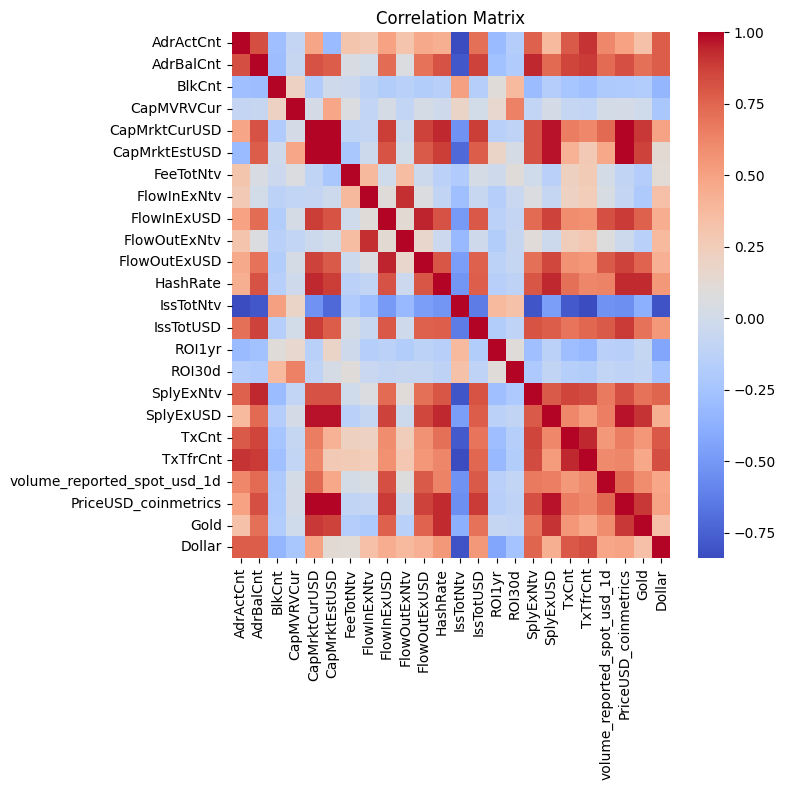

CapMVRVCur                     0.016413
FlowOutExNtv                  -0.031187
FlowInExNtv                   -0.082761
FeeTotNtv                     -0.097449
ROI30d                        -0.107268
ROI1yr                        -0.149928
BlkCnt                        -0.193192
Dollar                         0.494769
AdrActCnt                      0.500958
IssTotNtv                     -0.545371
TxTfrCnt                       0.622907
TxCnt                          0.661398
volume_reported_spot_usd_1d    0.743949
AdrBalCnt                      0.821406
SplyExNtv                      0.822008
FlowOutExUSD                   0.868940
FlowInExUSD                    0.885303
IssTotUSD                      0.889424
Gold                           0.893357
HashRate                       0.931277
SplyExUSD                      0.973293
CapMrktEstUSD                  0.999646
CapMrktCurUSD                  0.999698
PriceUSD_coinmetrics           1.000000
Name: PriceUSD_coinmetrics, dtype: float

In [5]:
# drop unuseful columns, and plot correlation heatmap

btc_merge.drop(columns=["AssetCompletionTime", 
                "AssetEODCompletionTime", 
                "PriceBTC", 
                "SplyCur",
                "PriceUSD",
                "SplyExpFut10yr",
                "ReferenceRate", 
                "ReferenceRateETH",
                "ReferenceRateEUR",
                "ReferenceRateUSD"], 
                inplace = True)
btc_merge = btc_merge.loc["2010-07-18":]
corr_matrix, corr_heatmap = compute_plot_coor(btc_merge)
print(corr_matrix["PriceUSD_coinmetrics"].sort_values(key=abs))


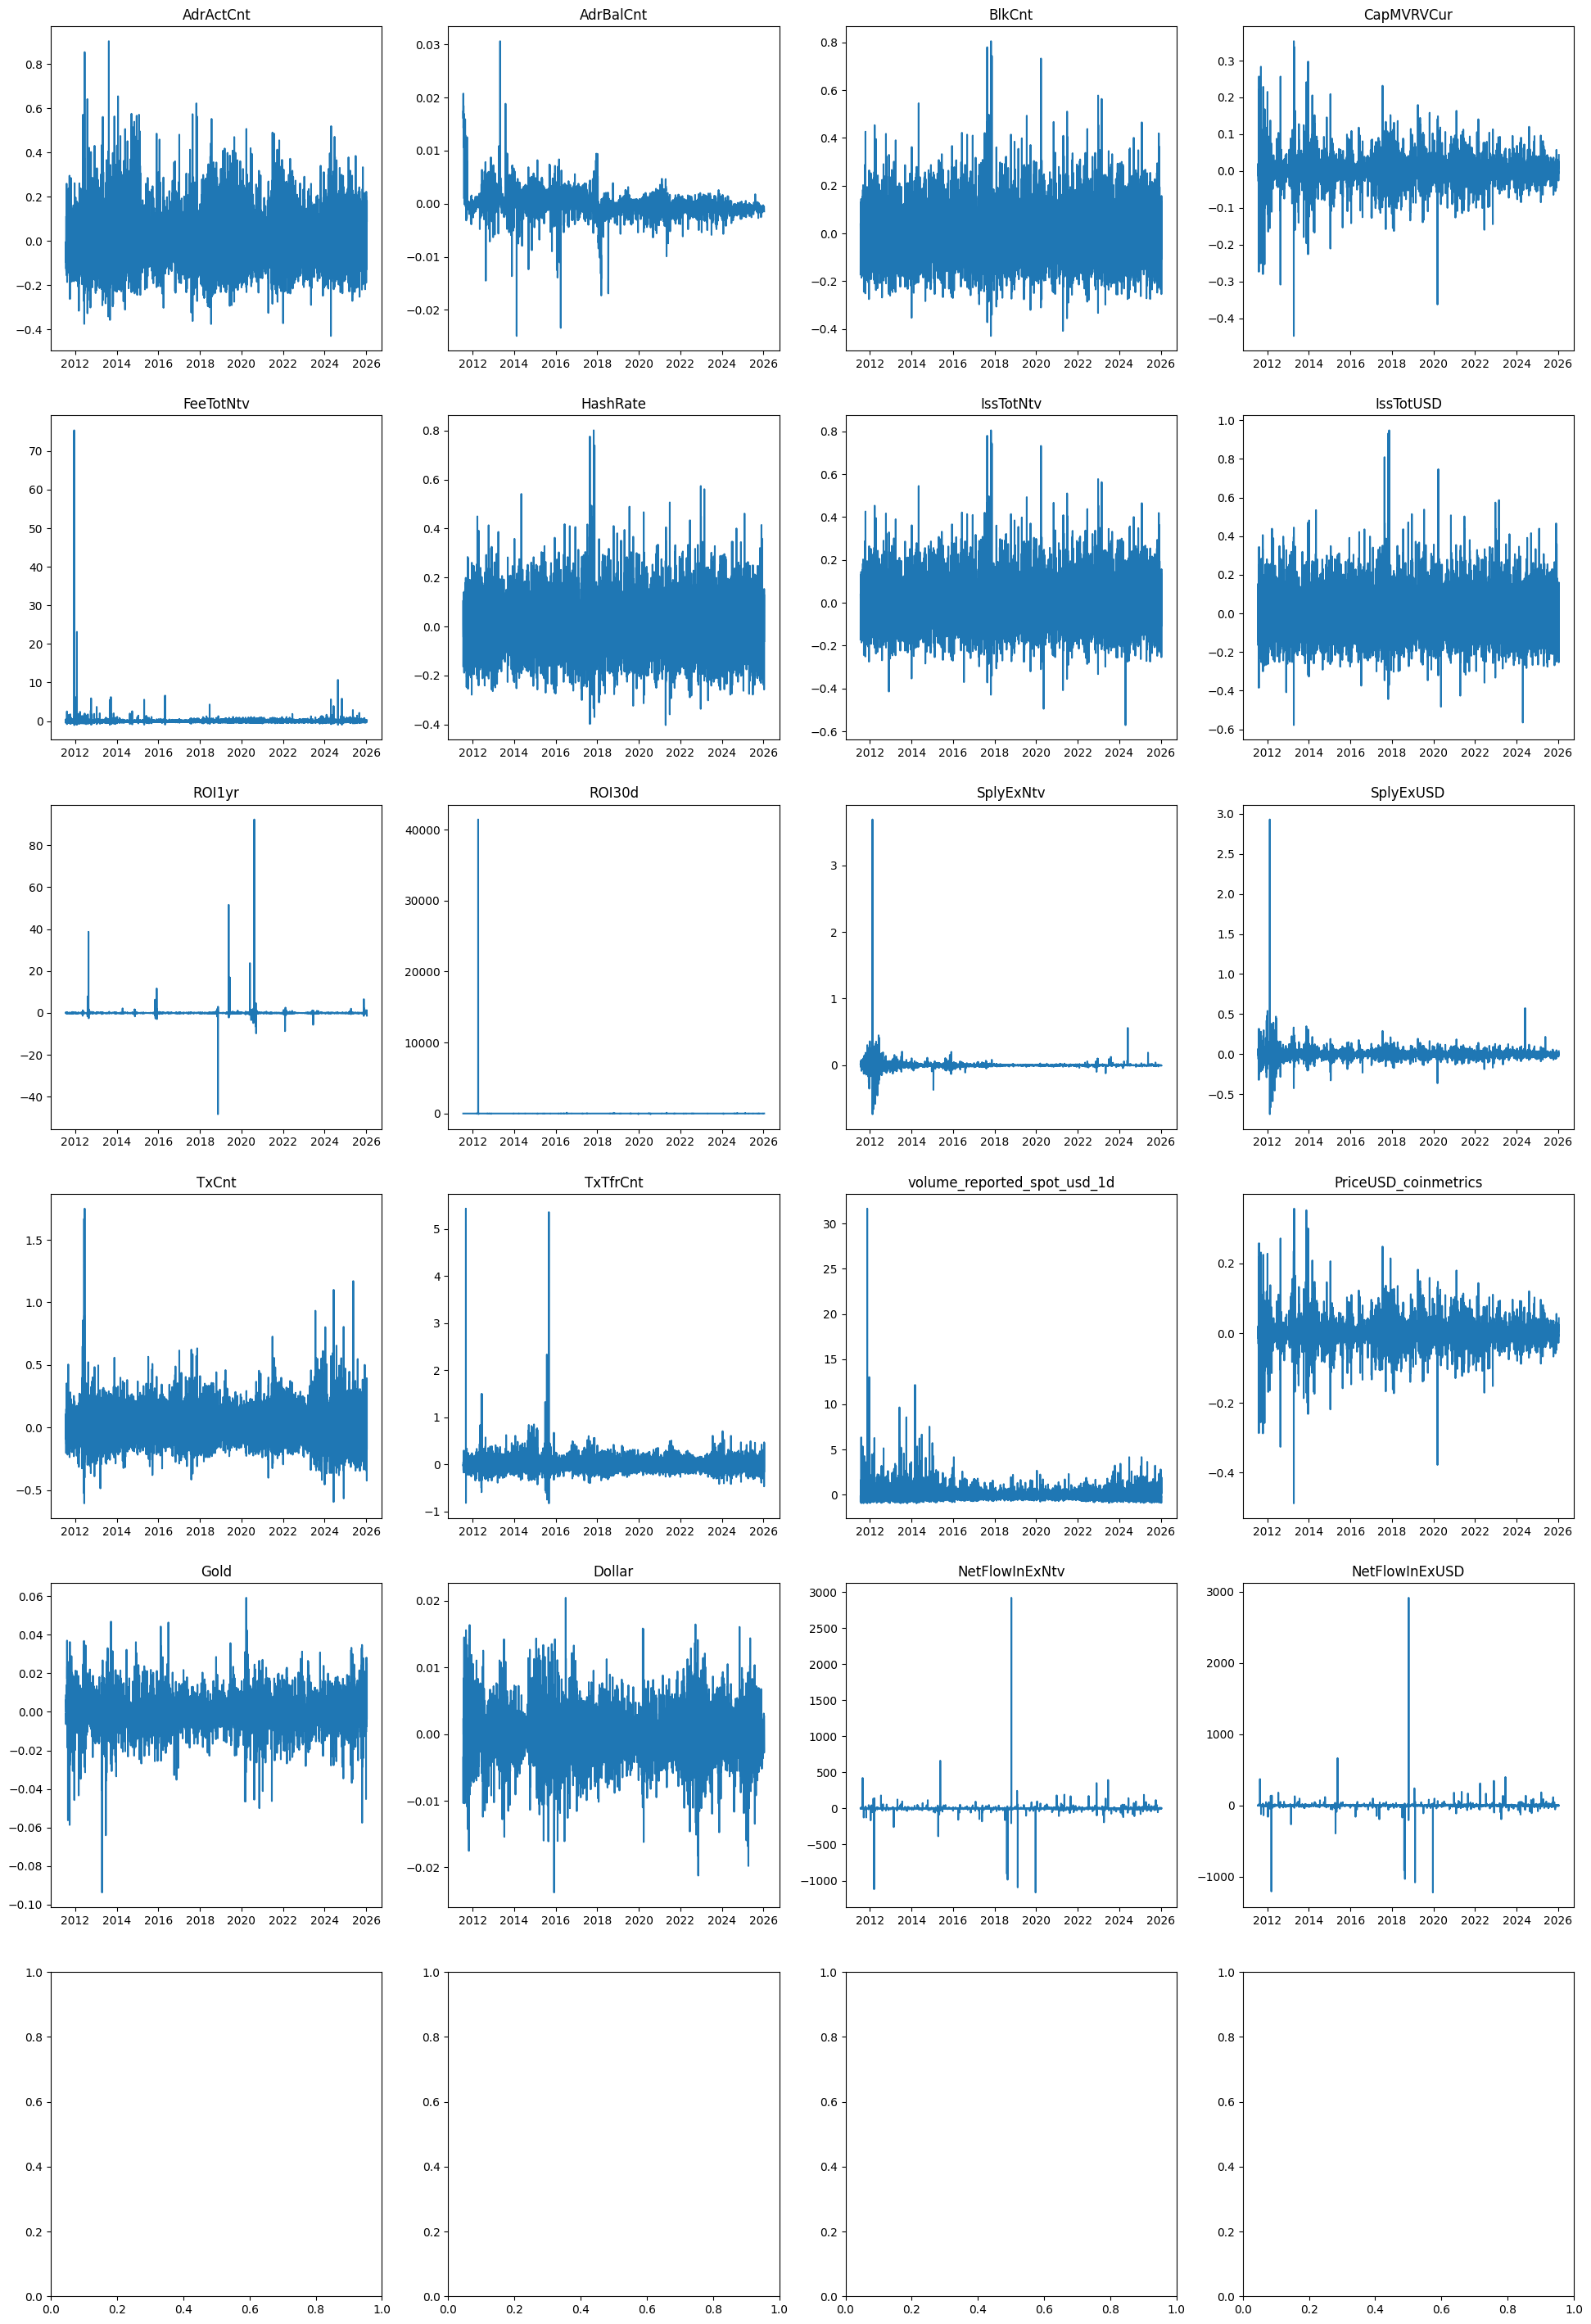

In [6]:
# Get 1 day difference data, and de-mean the data
# Market cap is identical to price, drop them
# Combine FlowInExUSD and FlowOutExUSD

NetFlowInExUSD = pd.DataFrame(btc_merge['FlowInExUSD'] - btc_merge["FlowOutExUSD"], columns=["NetFlowInExUSD"])
NetFlowInExNtv = pd.DataFrame(btc_merge["FlowInExNtv"] - btc_merge["FlowOutExNtv"], columns=["NetFlowInExNtv"])

btc_merge  = pd.merge(left=btc_merge, right=NetFlowInExNtv, how='left', left_index=True, right_index=True)
btc_merge = pd.merge(left=btc_merge, right=NetFlowInExUSD, how='left', left_index=True, right_index=True)

btc_merge.drop(columns=["CapMrktEstUSD", "CapMrktCurUSD", "FlowInExUSD", "FlowOutExUSD", "FlowInExNtv", "FlowOutExNtv"], inplace=True)
btc_1d_diff_demean = differatiate_data(btc_merge, period=1)
diff_1d_ts_plot = plot_ts(btc_1d_diff_demean)

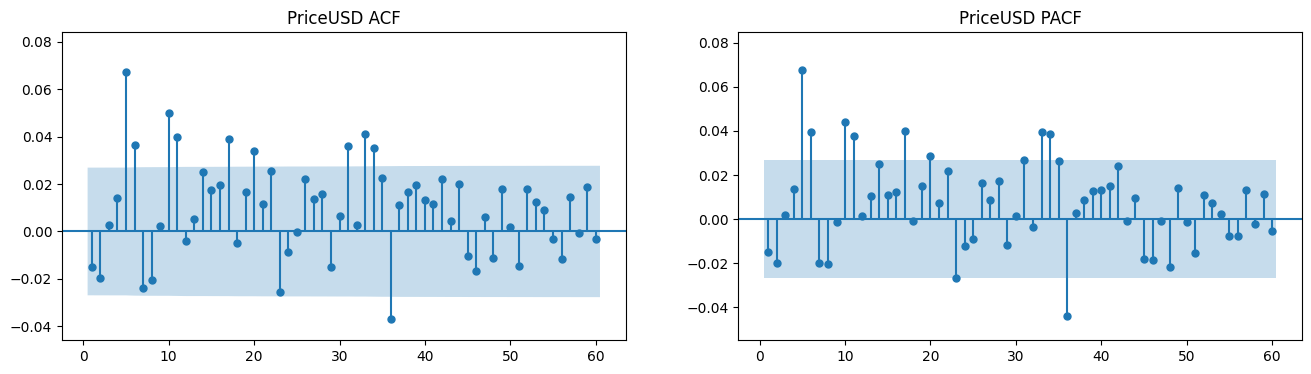

In [7]:
# The apparent paradigm shifts of 'SplyCur' and 'SplyExpFut10yr' are noises to our target 'PriceUSD_coinmetrics'.
# acf/pacf plot of 1 day differentiated data

# res, acf_pacf_plot = acf_pacf_plot(btc_1d_diff_demean)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2,figsize=(16,4))
plot_acf(btc_1d_diff_demean["PriceUSD_coinmetrics"], lags=60, ax=ax[0], title="PriceUSD ACF", zero=False, auto_ylims=True)
plot_pacf(btc_1d_diff_demean["PriceUSD_coinmetrics"], lags=60, ax=ax[1], title="PriceUSD PACF", zero=False, auto_ylims=True)
plt.show()

In [8]:
# Augment Dicky-Fuller Test check stationary

adf = AD_Fuller_Test(btc_1d_diff_demean)
print("Feature Name \t\t Statistics \t\t pvalue \n==============================================================")
for k,v in adf.items():
    if k != 'critic value':
        print(f"{k.ljust(15)} \t\t {str(round(v['AD_Fuller_Statistics'], 4)).ljust(10)} \t\t {round(v['pvalue'], 4)}")

Feature Name 		 Statistics 		 pvalue 
AdrActCnt       		 -12.9675   		 0.0
AdrBalCnt       		 -7.9583    		 0.0
BlkCnt          		 -19.6565   		 0.0
CapMVRVCur      		 -22.4838   		 0.0
FeeTotNtv       		 -74.583    		 0.0
HashRate        		 -9.5093    		 0.0
IssTotNtv       		 -19.9796   		 0.0
IssTotUSD       		 -40.696    		 0.0
ROI1yr          		 -43.4019   		 0.0
ROI30d          		 -72.7487   		 0.0
SplyExNtv       		 -11.9378   		 0.0
SplyExUSD       		 -15.0824   		 0.0
TxCnt           		 -11.274    		 0.0
TxTfrCnt        		 -11.8632   		 0.0
volume_reported_spot_usd_1d 		 -9.4792    		 0.0
PriceUSD_coinmetrics 		 -9.8767    		 0.0
Gold            		 -75.7981   		 0.0
Dollar          		 -73.4956   		 0.0
NetFlowInExNtv  		 -53.2154   		 0.0
NetFlowInExUSD  		 -53.1287   		 0.0


In [9]:
# vector auto-regressive model fitting
var_results = vec_ar_test(btc_1d_diff_demean, y = "PriceUSD_coinmetrics")
var_results.summary()

# The model choose optimal BIC lag to be ONE. This is doubtful.
# The price equation suggests that statisticall significant variables are:
#   Variable                        coef            pvalue
#   'AdrBalCnt'                     -0.504703       0.042 
#   'CapMVRVCur'                    -0.239659,      0.007
#   'ROI1yr',                        0.000761       0.019
#   'volume_reported_spot_usd_1d'    0.001655       0.019, 
#   'PriceUSD_coinmetrics'           0.298828       0.087
#   'Gold'                           0.191949       0.008

The optimal BIC lags number is 1


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Feb, 2026
Time:                     17:26:04
--------------------------------------------------------------------
No. of Equations:         20.0000    BIC:                   -85.3044
Nobs:                     5292.00    HQIC:                  -85.6438
Log likelihood:           77335.6    FPE:                5.32309e-38
AIC:                     -85.8262    Det(Omega_mle):     4.91772e-38
--------------------------------------------------------------------
Results for equation AdrActCnt
                                    coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------
const                                  0.000016         0.001692            0.010           0.992
L1.AdrActCnt                          -0.254726         0.017238          -14.777     

In [10]:
# run granger causality test, try lags=3
gc_btc_1d_diff_demean = granger_test(btc_1d_diff_demean, y='PriceUSD_coinmetrics', lags=3)

# Granger test shows discrepency with VAR test. This may be due to possible stong cointegrations.
# Granger test suggest these variables are significant at 0.05 level:
#       Variable name           lags
# ================================================
#       AdrActCnt               L1,L2,L3
#       AdrBalCnt               L2, L3
#       CapMVRVCur              L1,L2,L3
#       FeeTotNtv               L1
#       HashRate                L3
#       ISSTotUSD               L1,L2,L3
#       SplyExUSD               L1,L2,L3
#       TxCnt                   L1,L2,L3
#       TxTfrCnt                L2
#       Gold                    L1,L2,L3
#       Dollar                  L1,L2,L3

Testing Granger Causality from AdrActCnt to PriceUSD_coinmetrics

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=21.6638 , p=0.0000  , df_denom=5289, df_num=1
ssr based chi2 test:   chi2=21.6761 , p=0.0000  , df=1
likelihood ratio test: chi2=21.6318 , p=0.0000  , df=1
parameter F test:         F=21.6638 , p=0.0000  , df_denom=5289, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=15.5966 , p=0.0000  , df_denom=5286, df_num=2
ssr based chi2 test:   chi2=31.2227 , p=0.0000  , df=2
likelihood ratio test: chi2=31.1310 , p=0.0000  , df=2
parameter F test:         F=15.5966 , p=0.0000  , df_denom=5286, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=13.8765 , p=0.0000  , df_denom=5283, df_num=3
ssr based chi2 test:   chi2=41.6846 , p=0.0000  , df=3
likelihood ratio test: chi2=41.5212 , p=0.0000  , df=3
parameter F test:         F=13.8765 , p=0.0000  , df_denom=5283, df_num=3
Testing Granger Causali

In [11]:
# Johansen cointegration test only support 12 variables
data = btc_merge[["AdrBalCnt", "BlkCnt",  "FeeTotNtv", "CapMVRVCur", "HashRate", "IssTotNtv", 
                  "TxTfrCnt", "volume_reported_spot_usd_1d", "PriceUSD_coinmetrics", "Gold", "Dollar"]]

rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)
print(vecm_result)
# Strong Cointegration confirmed

Rank 0: trace=4343.834, critical=285.140
Rank 1: trace=2898.576, critical=239.247
Rank 2: trace=1910.858, critical=197.377
Rank 3: trace=1200.774, critical=159.529
Rank 4: trace=597.559, critical=125.618
Rank 5: trace=305.882, critical=95.754
Rank 6: trace=108.166, critical=69.819
Rank 7: trace=51.522, critical=47.855
Rank 8: trace=22.239, critical=29.796
Rank 9: trace=9.220, critical=15.494
Rank 10: trace=0.831, critical=3.841
Rank 0: max eig=1445.258, critical=70.539
Rank 1: max eig=987.718, critical=64.504
Rank 2: max eig=710.084, critical=58.433
Rank 3: max eig=603.215, critical=52.362
Rank 4: max eig=291.677, critical=46.230
Rank 5: max eig=197.716, critical=40.076
Rank 6: max eig=56.645, critical=33.878
Rank 7: max eig=29.282, critical=27.586
Rank 8: max eig=13.020, critical=21.131
Rank 9: max eig=8.388, critical=14.264
Rank 10: max eig=0.831, critical=3.841
cointegration rank: 8
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


In [12]:
interpret_vecm_results(vecm_result)

# total of 8 cointegration relationships

# cointegration 1 (after normalisation):
#   0 = - 1505.6760*Dollar - 1.1067*Gold PriceUSD_coinmetrics

# cointegration 2 (after normalisation):
#   0 = + 13345.4680*BlkCnt + 10168.4132*Dollar + 126.3374*Gold PriceUSD_coinmetrics

# cointegration 3 (after normalisation):
#   0 = + 668.6323*FeeTotNtv - 400.1748*Dollar + 17.6010*Gold PriceUSD_coinmetrics

# cointegration 4 (after normalisation):
#   0 = + 24379.5933*CapMVRVCur + 1107.4678*Dollar + 22.6536*Gold PriceUSD_coinmetrics

# cointegration 5 (after normalisation):
#   0 = - 2664.4001*Dollar - 99.5348*Gold PriceUSD_coinmetrics

# cointegration 6 (after normalisation):
#   0 = + 2215.4826*Dollar + 10.1783*IssTotNtv PriceUSD_coinmetrics + 0.7747*Gold

1. erro correction efficient towards long term equilibrium）

total of 8 erro correction items (cointegration relationships)

erro correction coeficients:
                   Variable Cointegrating_Vector         Alpha    Std_Error      P_Value Significance
                  AdrBalCnt                  EC1 -7.410968e-04 7.175529e-05 0.000000e+00          ***
                  AdrBalCnt                  EC2  6.144911e+01 3.212517e+01 5.577334e-02            *
                  AdrBalCnt                  EC3  1.648087e+01 6.268019e+00 8.554610e-03          ***
                  AdrBalCnt                  EC4  9.602849e+02 5.194646e+02 6.451484e-02            *
                  AdrBalCnt                  EC5 -9.483085e-06 8.258010e-06 2.508241e-01             
                  AdrBalCnt                  EC6 -2.243069e-01 4.250151e-01 5.976644e-01             
                  AdrBalCnt                  EC7  3.429735e-02 4.604466e-03 9.414691e-14          ***
                  AdrBalCnt   

(     Variable Cointegrating_Vector         Alpha     Std_Error   P_Value  \
 0   AdrBalCnt                  EC1 -7.410968e-04  7.175529e-05  0.000000   
 1   AdrBalCnt                  EC2  6.144911e+01  3.212517e+01  0.055773   
 2   AdrBalCnt                  EC3  1.648087e+01  6.268019e+00  0.008555   
 3   AdrBalCnt                  EC4  9.602849e+02  5.194646e+02  0.064515   
 4   AdrBalCnt                  EC5 -9.483085e-06  8.258010e-06  0.250824   
 ..        ...                  ...           ...           ...       ...   
 83     Dollar                  EC4 -1.005040e-02  5.019929e-03  0.045274   
 84     Dollar                  EC5 -2.685664e-11  7.980260e-11  0.736465   
 85     Dollar                  EC6 -2.694461e-06  4.107201e-06  0.511803   
 86     Dollar                  EC7  6.751822e-08  4.449600e-08  0.129166   
 87     Dollar                  EC8 -2.150411e-12  1.148651e-12  0.061190   
 
    Significance  
 0           ***  
 1             *  
 2           *** 

In [13]:
#### Explaination:
# 1. Key insights: 
# (1) Variables show complex and strong cointegrations (8 in total).
# (2) Target variable (PriceUSD_coinmetrics) is price finder not price taker.

# 2. Short term dynamics:
# (1) ΔAdrBalCnt_t-1：-0.000635（p=0.0544*）
# (2) ΔPriceUSD_coinmetrics_t-1：-0.028133（p=0.0386**）

# 3. Long term dynamics (top 6 cointegrations):
# (1) 0 = PriceUSD_coinmetrics - 1505.68*Dollar - 1.1067*Gold; 
# (2) 0 = PriceUSD_coinmetrics + 13345.47*BlkCnt + 10168.41*Dollar + 126.34*Gold; 
# (3) 0 = PriceUSD_coinmetrics + 668.63*FeeTotNtv - 400.17*Dollar + 17.60*Gold; 
# (4) 0 = PriceUSD_coinmetrics + 24379.59*CapMVRVCur + 1107.47*Dollar + 22.65*Gold; 
# (5) 0 = PriceUSD_coinmetrics - 2664.40*Dollar - 99.53*Gold; 
# (6) 0 = PriceUSD_coinmetrics + 2215.48*Dollar + 10.18*IssTotNtv + 0.7747*Gold;

# significant correction variables of first cointegration:
# ============================================================================
#                   Variable         Alpha   Direction  P_Value Significance
# ============================================================================
#  volume_reported_spot_usd_1d  1.026043e+02   ↑ upwards 0.000000          ***
#                     HashRate  5.971085e-01   ↑ upwards 0.000000          ***
#                     TxTfrCnt  3.569417e-03   ↑ upwards 0.000000          ***
#                    AdrBalCnt -7.410968e-04 ↓ downwards 0.000000          ***
#                       BlkCnt  1.462194e-07   ↑ upwards 0.000004          ***
#                   CapMVRVCur  7.834212e-10   ↑ upwards 0.047107           **

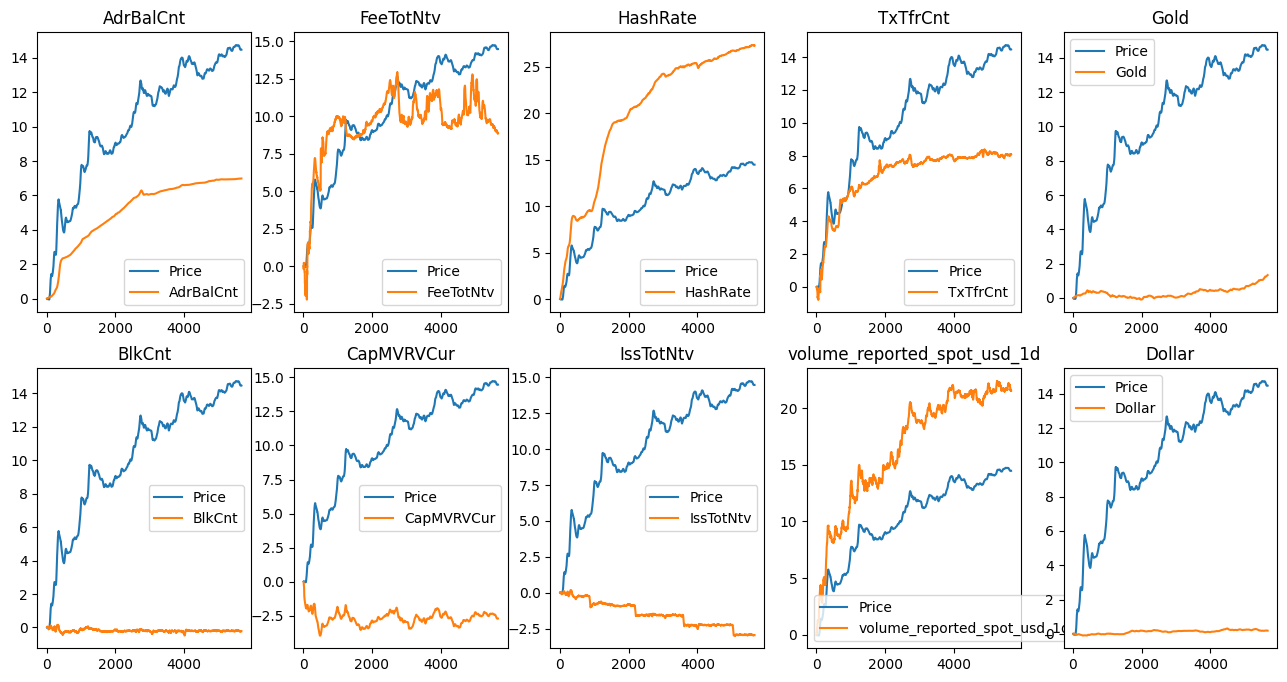

In [15]:
fig,ax = plt.subplots(2,5,figsize=(16,8))
coordinates = [[i,j] for j in range(5) for i in range(2)]

d = data['PriceUSD_coinmetrics'].rolling(window=30, min_periods=15).mean().pct_change().cumsum()
k = 0
for col in data.columns:
    if col != 'PriceUSD_coinmetrics':
        e = data[col].rolling(window=30, min_periods=15).mean().pct_change().cumsum()
        i, j = coordinates[k]
        ax[i][j].plot(np.arange(len(data)), d, label='Price')
        ax[i][j].plot(np.arange(len(data)), e, label=col)
        ax[i][j].set_title(col)
        ax[i][j].legend()
        k += 1

# From below plots, we may choose to use 'AdrBalCnt', 'FeeTotNtv', 'HashRate', 'TxTfrCnt', 'volume_reported_spot_usd_1d' to test mean-reversion force.
# It seems positive correlation exists between ['AdrBalCnt', 'FeeTotNtv', 'TxTfrCnt'] and 'Price'. The sharper increase of 'Price' may comes from its' autoregressive momentum. 
# Variables ['HashRate', 'volume_reported_spot_usd_1d'] enjoy deeper slope than price.       

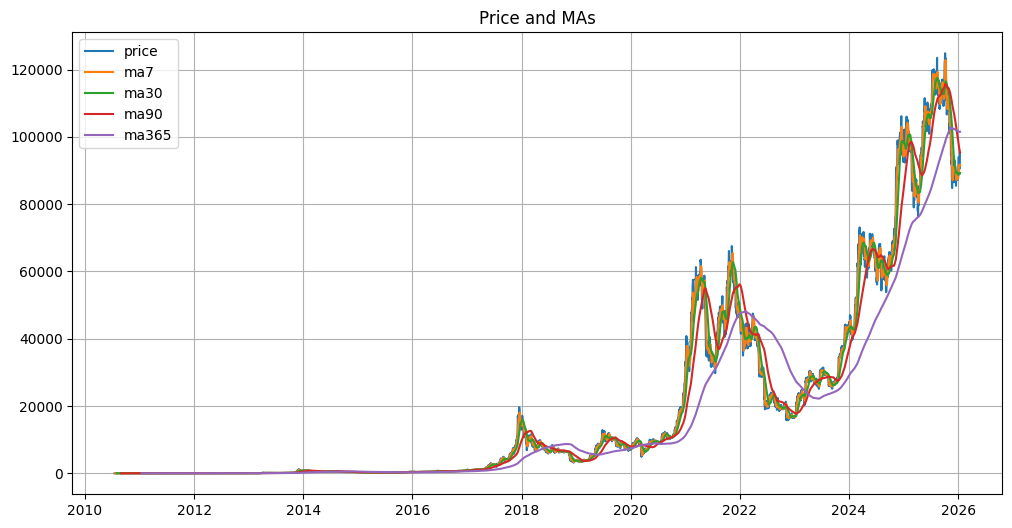

In [16]:
price = btc_merge['PriceUSD_coinmetrics']
ma7 = price.rolling(window=7, min_periods=3).mean()
ma30 = price.rolling(window=30, min_periods=15).mean()
ma90 = price.rolling(window=90, min_periods=45).mean()
ma365 = price.rolling(window=365, min_periods=182).mean()
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(btc_merge['PriceUSD_coinmetrics'], label='price')
ax.plot(ma7, label='ma7')
ax.plot(ma30, label='ma30')
ax.plot(ma90, label='ma90')
ax.plot(ma365, label='ma365')
ax.set_title('Price and MAs')
ax.grid()
ax.legend()
plt.show()

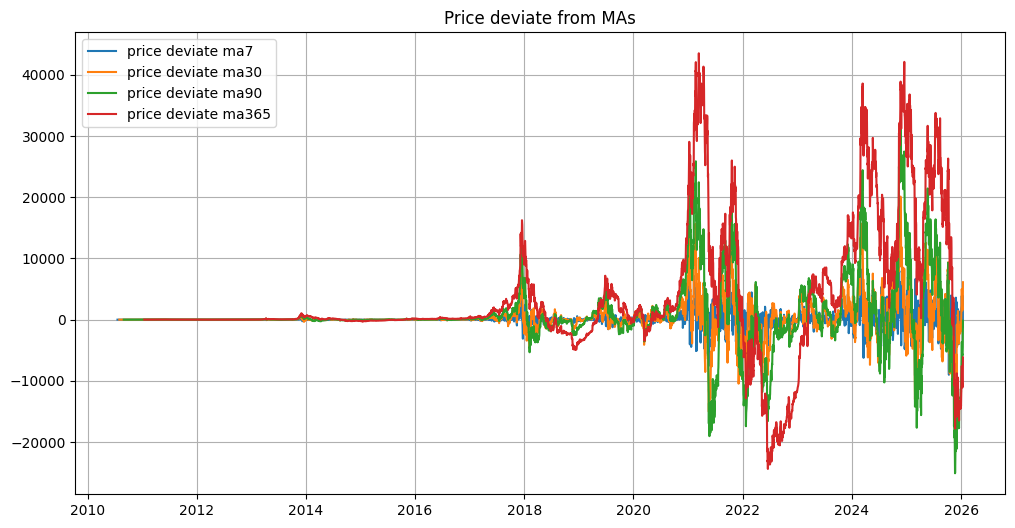

In [17]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(price - ma7, label='price deviate ma7')
ax.plot(price - ma30, label='price deviate ma30')
ax.plot(price - ma90, label='price deviate ma90')
ax.plot(price - ma365, label='price deviate ma365')
ax.set_title('Price deviate from MAs')
ax.grid()
ax.legend()
plt.show()
# There exists strong reversion force when price deviates from MAs.

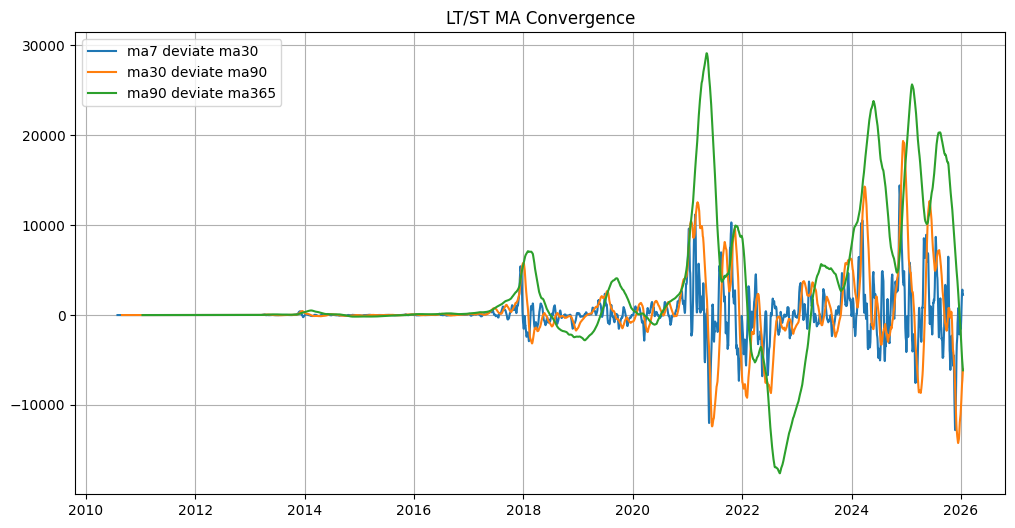

In [18]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(ma7 - ma30, label='ma7 deviate ma30')
ax.plot(ma30 - ma90, label='ma30 deviate ma90')
ax.plot(ma90 - ma365, label='ma90 deviate ma365')
ax.set_title('LT/ST MA Convergence')
ax.grid()
ax.legend()
plt.show()
# There exists reversion force pushes short term MA to longer MA. We may exploit this structure for our allocation of weights.

### 2. Poly market data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os

notebook_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.insert(0, project_root)

from template.prelude_template import load_polymarket_data, load_data
from eda.EDA import *

#### 2.1 features on Trilemma method, using btc markets and weighted volume 

In [20]:
poly_market = POLY()
features = poly_market.prepare_features()

2026-02-21 17:33:39 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-02-21 17:33:39 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-02-21 17:33:39 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-02-21 17:33:39 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-02-21 17:33:39 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-02-21 17:33:54 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:33:57 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-02-21 17:33:57 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-02-21 17:33:57 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:33:57 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-02-21 17:33:57 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-02-21 17:33:57 INFO       Loaded 440

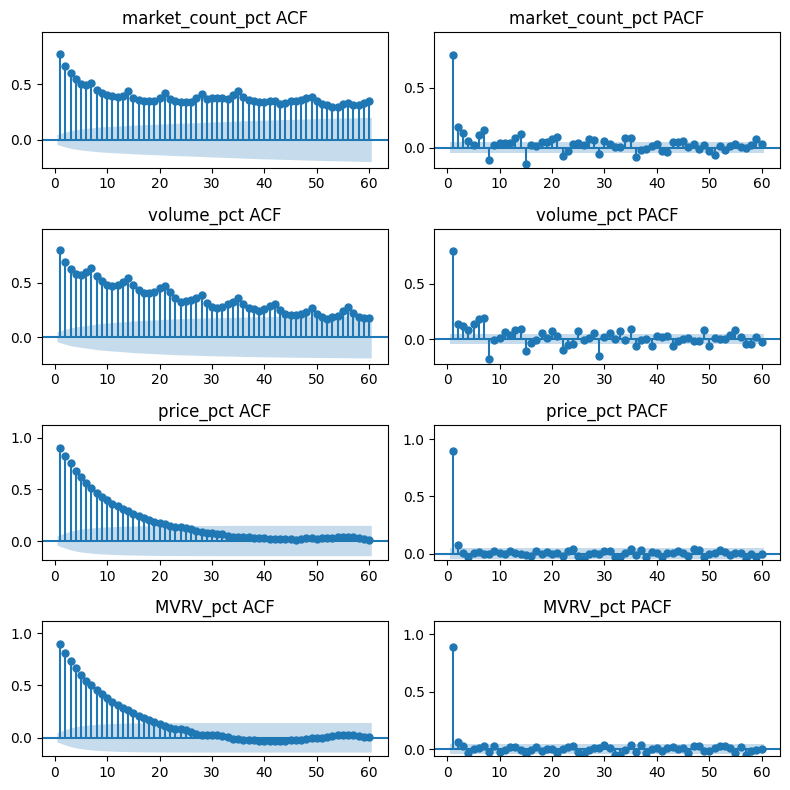

In [21]:
res, plot = acf_pacf_plot(features[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])


In [22]:
# Augment Dicky-Fuller Test check stationary

adf = AD_Fuller_Test(features[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])
print("Feature Name \t\t Statistics \t\t pvalue \n==============================================================")
for k,v in adf.items():
    if k != 'critic value':
        print(f"{k.ljust(15)} \t\t {str(round(v['AD_Fuller_Statistics'], 4)).ljust(10)} \t\t {round(v['pvalue'], 4)}")


Feature Name 		 Statistics 		 pvalue 
market_count_pct 		 -3.6061    		 0.0056
volume_pct      		 -4.4365    		 0.0003
price_pct       		 -9.1227    		 0.0
MVRV_pct        		 -9.5118    		 0.0


In [23]:
# vector auto-regressive model fitting
var_results = vec_ar_test(features[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct")
var_results.summary()

# significant varialbes for equation price_pct:
# ====================================================
#   variable                coef                pvalue
# ====================================================
#   MVRV_pct/L1             0.117672            0.020
#   price_pct/L1            0.721150            0.000
#   price_pct/L2            0.115791            0.024

The optimal BIC lags number is 2


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Feb, 2026
Time:                     17:34:20
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -15.2219
Nobs:                     1929.00    HQIC:                  -15.2876
Log likelihood:           3869.20    FPE:                2.20846e-07
AIC:                     -15.3258    Det(Omega_mle):     2.16772e-07
--------------------------------------------------------------------
Results for equation market_count_pct
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.027765         0.009860            2.816           0.005
L1.market_count_pct         0.643494         0.023874           26.954           0.000
L1.volume_pct            

In [24]:
# run granger causality test, try lags=3
gc_btc_1d_diff_demean = granger_test(features[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct", lags=3)

# Granger Causality from variables to price_pct:

# ==============================================
#       variable        lag         pvalue
# ==============================================
#       volume_pct      L1          0.0381
#       volume_pct      L2          0.0896
#       MVRV_pct        L2          0.0539
#       MVRV_pct        L3          0.0027

Testing Granger Causality from market_count_pct to price_pct

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1
ssr based chi2 test:   chi2=0.1798  , p=0.6715  , df=1
likelihood ratio test: chi2=0.1798  , p=0.6715  , df=1
parameter F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2
ssr based chi2 test:   chi2=0.3459  , p=0.8412  , df=2
likelihood ratio test: chi2=0.3459  , p=0.8412  , df=2
parameter F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
ssr based chi2 test:   chi2=0.5274  , p=0.9128  , df=3
likelihood ratio test: chi2=0.5273  , p=0.9128  , df=3
parameter F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
Testing Granger Causality f

In [25]:
data = features[["daily_market_count", "daily_volume",  "PriceUSD_coinmetrics", 'CapMVRVCur']]

rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)

# find 3 cointegrations in a 4 dimension dataset


Rank 0: trace=386.659, critical=47.855
Rank 1: trace=114.129, critical=29.796
Rank 2: trace=27.514, critical=15.494
Rank 3: trace=2.152, critical=3.841
Rank 0: max eig=272.530, critical=27.586
Rank 1: max eig=86.615, critical=21.131
Rank 2: max eig=25.362, critical=14.264
Rank 3: max eig=2.152, critical=3.841
cointegration rank: 3
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


In [26]:
interpret_vecm_results(vecm_result)

# in long run, CapMVRVCur cointegrates with all other variables
# total of 3 cointegration relationships

# cointegration 1 (after normalisation):
#   0 = + 364.7201*CapMVRVCur + 1.0000*daily_market_count

# cointegration 2 (after normalisation):
#   0 = + 23266157.7833*CapMVRVCur + 1.0000*daily_volume

# cointegration 3 (after normalisation):
#   0 = + 396297.2779*CapMVRVCur + 1.0000*PriceUSD_coinmetrics

1. erro correction efficient towards long term equilibrium）

total of 3 erro correction items (cointegration relationships)

erro correction coeficients:
            Variable Cointegrating_Vector         Alpha    Std_Error      P_Value Significance
  daily_market_count                  EC1 -9.708084e-02 1.453636e-02 2.414291e-11          ***
  daily_market_count                  EC2 -8.562383e-07 1.903047e-07 6.817716e-06          ***
  daily_market_count                  EC3  1.345283e-04 1.305995e-05 0.000000e+00          ***
        daily_volume                  EC1  3.694133e+03 1.747619e+03 3.453151e-02           **
        daily_volume                  EC2 -3.683658e-01 2.287918e-02 0.000000e+00          ***
        daily_volume                  EC3  1.780405e+01 1.570119e+00 0.000000e+00          ***
PriceUSD_coinmetrics                  EC1 -1.812177e+00 1.164764e+00 1.197481e-01             
PriceUSD_coinmetrics                  EC2  2.653190e-05 1.524866e-05 8.186795e-02     

(                Variable Cointegrating_Vector         Alpha     Std_Error  \
 0     daily_market_count                  EC1 -9.708084e-02  1.453636e-02   
 1     daily_market_count                  EC2 -8.562383e-07  1.903047e-07   
 2     daily_market_count                  EC3  1.345283e-04  1.305995e-05   
 3           daily_volume                  EC1  3.694133e+03  1.747619e+03   
 4           daily_volume                  EC2 -3.683658e-01  2.287918e-02   
 5           daily_volume                  EC3  1.780405e+01  1.570119e+00   
 6   PriceUSD_coinmetrics                  EC1 -1.812177e+00  1.164764e+00   
 7   PriceUSD_coinmetrics                  EC2  2.653190e-05  1.524866e-05   
 8   PriceUSD_coinmetrics                  EC3  9.738063e-05  1.046463e-03   
 9             CapMVRVCur                  EC1 -2.737231e-05  4.595040e-05   
 10            CapMVRVCur                  EC2  9.551300e-10  6.015658e-10   
 11            CapMVRVCur                  EC3 -4.267163e-08  4.

#### 2.2 features on Trilemma method, using all crypto markets and weighted volume 

In [27]:
poly_market2 = POLY(btc_only=False)
features2 = poly_market2.prepare_features()

2026-02-21 17:34:52 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-02-21 17:34:52 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-02-21 17:34:52 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-02-21 17:34:52 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-02-21 17:34:52 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-02-21 17:35:04 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:35:07 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-02-21 17:35:07 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-02-21 17:35:07 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:35:07 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-02-21 17:35:07 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-02-21 17:35:07 INFO       Loaded 440

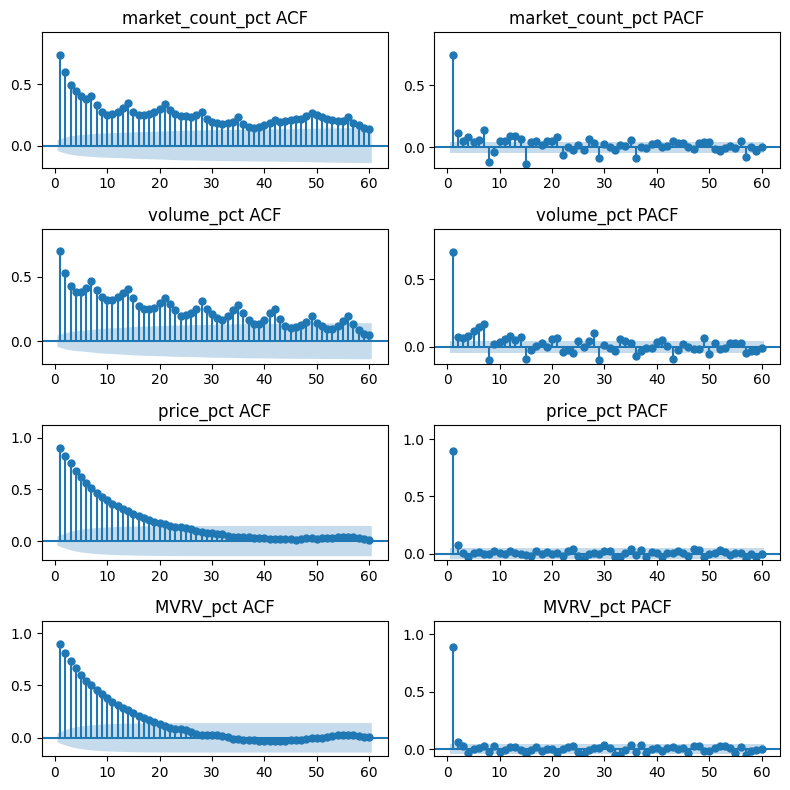

In [28]:
res, plot = acf_pacf_plot(features2[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])

In [29]:
# Augment Dicky-Fuller Test check stationary

adf = AD_Fuller_Test(features2[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])
print("Feature Name \t\t Statistics \t\t pvalue \n==============================================================")
for k,v in adf.items():
    if k != 'critic value':
        print(f"{k.ljust(15)} \t\t {str(round(v['AD_Fuller_Statistics'], 4)).ljust(10)} \t\t {round(v['pvalue'], 4)}")

Feature Name 		 Statistics 		 pvalue 
market_count_pct 		 -4.3865    		 0.0003
volume_pct      		 -4.7227    		 0.0001
price_pct       		 -9.1227    		 0.0
MVRV_pct        		 -9.5118    		 0.0


In [30]:
# vector auto-regressive model fitting
var_results = vec_ar_test(features2[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct")
var_results.summary()

# significant varialbes for equation price_pct:
# ====================================================
#   variable                coef                pvalue
# ====================================================
#   MVRV_pct/L1             0.113909            0.020
#   price_pct/L1            0.724770            0.000
#   price_pct/L2            0.115888            0.024

The optimal BIC lags number is 2


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Feb, 2026
Time:                     17:35:26
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -14.4740
Nobs:                     1929.00    HQIC:                  -14.5397
Log likelihood:           3147.84    FPE:                4.66558e-07
AIC:                     -14.5779    Det(Omega_mle):     4.57952e-07
--------------------------------------------------------------------
Results for equation market_count_pct
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.077287         0.012727            6.073           0.000
L1.market_count_pct         0.655116         0.024886           26.325           0.000
L1.volume_pct            

In [31]:
# run granger causality test, try lags=3
gc_btc_1d_diff_demean = granger_test(features2[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct", lags=3)

# Granger Causality from variables to price_pct:

# ==============================================
#       variable        lag         pvalue
# ==============================================
#       MVRV_pct        L2          0.0539
#       MVRV_pct        L3          0.0027

Testing Granger Causality from market_count_pct to price_pct

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2579  , p=0.6116  , df_denom=1927, df_num=1
ssr based chi2 test:   chi2=0.2583  , p=0.6113  , df=1
likelihood ratio test: chi2=0.2583  , p=0.6113  , df=1
parameter F test:         F=0.2579  , p=0.6116  , df_denom=1927, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1931  , p=0.8245  , df_denom=1924, df_num=2
ssr based chi2 test:   chi2=0.3871  , p=0.8240  , df=2
likelihood ratio test: chi2=0.3871  , p=0.8240  , df=2
parameter F test:         F=0.1931  , p=0.8245  , df_denom=1924, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4040  , p=0.7502  , df_denom=1921, df_num=3
ssr based chi2 test:   chi2=1.2163  , p=0.7491  , df=3
likelihood ratio test: chi2=1.2159  , p=0.7492  , df=3
parameter F test:         F=0.4040  , p=0.7502  , df_denom=1921, df_num=3
Testing Granger Causality f

In [32]:
data = features2[["daily_market_count", "daily_volume",  "PriceUSD_coinmetrics", 'CapMVRVCur']]

rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)

Rank 0: trace=372.130, critical=47.855
Rank 1: trace=71.534, critical=29.796
Rank 2: trace=22.956, critical=15.494
Rank 3: trace=2.176, critical=3.841
Rank 0: max eig=300.596, critical=27.586
Rank 1: max eig=48.578, critical=21.131
Rank 2: max eig=20.780, critical=14.264
Rank 3: max eig=2.176, critical=3.841
cointegration rank: 3
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


In [33]:
interpret_vecm_results(vecm_result)

# total of 3 cointegration relationships

# cointegration 1 (after normalisation):
#   0 = + 1059.3377*CapMVRVCur + 1.0000*daily_market_count

# cointegration 2 (after normalisation):
#   0 = + 40840190.9980*CapMVRVCur + 1.0000*daily_volume

# cointegration 3 (after normalisation):
#   0 = + 421946.4121*CapMVRVCur + 1.0000*PriceUSD_coinmetrics

1. erro correction efficient towards long term equilibrium）

total of 3 erro correction items (cointegration relationships)

erro correction coeficients:
            Variable Cointegrating_Vector         Alpha    Std_Error      P_Value Significance
  daily_market_count                  EC1 -3.384365e-02 9.886956e-03 6.192032e-04          ***
  daily_market_count                  EC2 -1.196743e-06 2.407518e-07 6.665738e-07          ***
  daily_market_count                  EC3  1.940947e-04 2.479704e-05 4.884981e-15          ***
        daily_volume                  EC1  4.997310e+03 9.975261e+02 5.451381e-07          ***
        daily_volume                  EC2 -4.259456e-01 2.429021e-02 0.000000e+00          ***
        daily_volume                  EC3  2.802958e+01 2.501851e+00 0.000000e+00          ***
PriceUSD_coinmetrics                  EC1 -4.487669e-01 4.447079e-01 3.129135e-01             
PriceUSD_coinmetrics                  EC2  6.575880e-06 1.082884e-05 5.436808e-01     

(                Variable Cointegrating_Vector         Alpha     Std_Error  \
 0     daily_market_count                  EC1 -3.384365e-02  9.886956e-03   
 1     daily_market_count                  EC2 -1.196743e-06  2.407518e-07   
 2     daily_market_count                  EC3  1.940947e-04  2.479704e-05   
 3           daily_volume                  EC1  4.997310e+03  9.975261e+02   
 4           daily_volume                  EC2 -4.259456e-01  2.429021e-02   
 5           daily_volume                  EC3  2.802958e+01  2.501851e+00   
 6   PriceUSD_coinmetrics                  EC1 -4.487669e-01  4.447079e-01   
 7   PriceUSD_coinmetrics                  EC2  6.575880e-06  1.082884e-05   
 8   PriceUSD_coinmetrics                  EC3  4.856827e-04  1.115352e-03   
 9             CapMVRVCur                  EC1 -4.845043e-06  1.754899e-05   
 10            CapMVRVCur                  EC2  3.794706e-10  4.273258e-10   
 11            CapMVRVCur                  EC3 -3.529130e-08  4.

#### 2.3 features on Trilemma method, using btc markets and original volume 

In [34]:
poly_market3 = POLY(btc_only=True)
features3 = poly_market3.prepare_features(use_benchmark=True)

2026-02-21 17:35:57 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-02-21 17:35:57 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-02-21 17:35:57 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-02-21 17:35:57 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-02-21 17:35:57 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-02-21 17:36:09 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:36:12 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-02-21 17:36:12 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-02-21 17:36:12 INFO       Fixing corrupted timestamps in column: timestamp
2026-02-21 17:36:12 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-02-21 17:36:12 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-02-21 17:36:12 INFO       Loaded 440

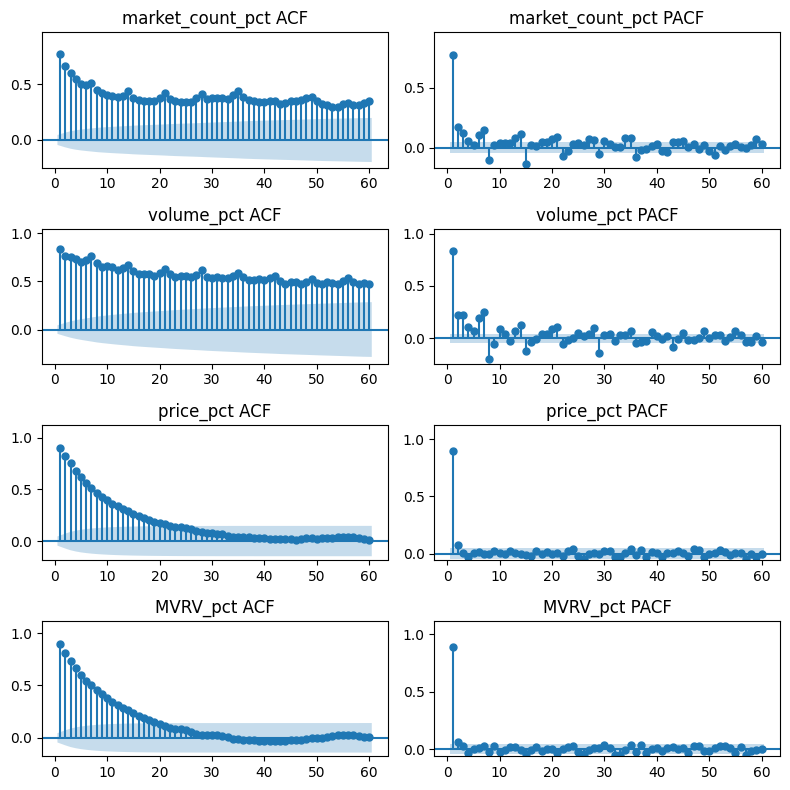

In [35]:
res, plot = acf_pacf_plot(features3[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])

In [36]:
adf = AD_Fuller_Test(features3[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])
print("Feature Name \t\t Statistics \t\t pvalue \n==============================================================")
for k,v in adf.items():
    if k != 'critic value':
        print(f"{k.ljust(15)} \t\t {str(round(v['AD_Fuller_Statistics'], 4)).ljust(10)} \t\t {round(v['pvalue'], 4)}")

Feature Name 		 Statistics 		 pvalue 
market_count_pct 		 -3.6061    		 0.0056
volume_pct      		 -2.8801    		 0.0477
price_pct       		 -9.1227    		 0.0
MVRV_pct        		 -9.5118    		 0.0


In [37]:
# vector auto-regressive model fitting
var_results = vec_ar_test(features3[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct")
var_results.summary()

# significant varialbes for equation price_pct:
# ====================================================
#   variable                coef                pvalue
# ====================================================
#   MVRV_pct/L1             0.118789            0.021
#   price_pct/L1            0.728760            0.000
#   price_pct/L2            0.115691            0.066

The optimal BIC lags number is 3


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Feb, 2026
Time:                     17:36:30
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -15.8663
Nobs:                     1928.00    HQIC:                  -15.9612
Log likelihood:           4548.97    FPE:                1.10703e-07
AIC:                     -16.0164    Det(Omega_mle):     1.07767e-07
--------------------------------------------------------------------
Results for equation market_count_pct
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.021500         0.009799            2.194           0.028
L1.market_count_pct         0.653137         0.026584           24.568           0.000
L1.volume_pct            

In [38]:
# run granger causality test, try lags=3
gc_btc_1d_diff_demean = granger_test(features3[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct", lags=3)

# Granger Causality from variables to price_pct:

# ==============================================
#       variable        lag         pvalue
# ==============================================
#       volume_pct      L1          0.0002
#       volume_pct      L2          0.0011
#       volume_pct      L3          0.0047
#       MVRV_pct        L2          0.0539
#       MVRV_pct        L3          0.0027

Testing Granger Causality from market_count_pct to price_pct

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1
ssr based chi2 test:   chi2=0.1798  , p=0.6715  , df=1
likelihood ratio test: chi2=0.1798  , p=0.6715  , df=1
parameter F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2
ssr based chi2 test:   chi2=0.3459  , p=0.8412  , df=2
likelihood ratio test: chi2=0.3459  , p=0.8412  , df=2
parameter F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
ssr based chi2 test:   chi2=0.5274  , p=0.9128  , df=3
likelihood ratio test: chi2=0.5273  , p=0.9128  , df=3
parameter F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
Testing Granger Causality f

In [39]:
# data = features3[["daily_market_count", "daily_volume",  "PriceUSD_coinmetrics", 'CapMVRVCur']].ffill()
data = features3[["daily_market_count", "daily_volume",  "PriceUSD_coinmetrics", 'CapMVRVCur']].loc[:'2025-12-31']
rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)

Rank 0: trace=565.151, critical=47.855
Rank 1: trace=118.882, critical=29.796
Rank 2: trace=29.260, critical=15.494
Rank 3: trace=2.759, critical=3.841
Rank 0: max eig=446.269, critical=27.586
Rank 1: max eig=89.623, critical=21.131
Rank 2: max eig=26.501, critical=14.264
Rank 3: max eig=2.759, critical=3.841
cointegration rank: 3
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


In [40]:
interpret_vecm_results(vecm_result)

# total of 3 cointegration relationships

# cointegration 1 (after normalisation):
#   0 = + 741.6643*CapMVRVCur + 1.0000*daily_market_count

# cointegration 2 (after normalisation):
#   0 = + 76978838.5049*CapMVRVCur + 1.0000*daily_volume

# cointegration 3 (after normalisation):
#   0 = + 813804.8510*CapMVRVCur + 1.0000*PriceUSD_coinmetrics

1. erro correction efficient towards long term equilibrium）

total of 3 erro correction items (cointegration relationships)

erro correction coeficients:
            Variable Cointegrating_Vector         Alpha    Std_Error      P_Value Significance
  daily_market_count                  EC1 -1.078500e-01 1.370778e-02 3.552714e-15          ***
  daily_market_count                  EC2 -6.274138e-07 1.259069e-07 6.255538e-07          ***
  daily_market_count                  EC3  1.547318e-04 1.480034e-05 0.000000e+00          ***
        daily_volume                  EC1  6.816587e+03 2.904366e+03 1.892454e-02           **
        daily_volume                  EC2 -5.870928e-01 2.667680e-02 0.000000e+00          ***
        daily_volume                  EC3  4.877662e+01 3.135854e+00 0.000000e+00          ***
PriceUSD_coinmetrics                  EC1 -1.586915e+00 1.095067e+00 1.472958e-01             
PriceUSD_coinmetrics                  EC2  2.606287e-05 1.005826e-05 9.564454e-03     

(                Variable Cointegrating_Vector         Alpha     Std_Error  \
 0     daily_market_count                  EC1 -1.078500e-01  1.370778e-02   
 1     daily_market_count                  EC2 -6.274138e-07  1.259069e-07   
 2     daily_market_count                  EC3  1.547318e-04  1.480034e-05   
 3           daily_volume                  EC1  6.816587e+03  2.904366e+03   
 4           daily_volume                  EC2 -5.870928e-01  2.667680e-02   
 5           daily_volume                  EC3  4.877662e+01  3.135854e+00   
 6   PriceUSD_coinmetrics                  EC1 -1.586915e+00  1.095067e+00   
 7   PriceUSD_coinmetrics                  EC2  2.606287e-05  1.005826e-05   
 8   PriceUSD_coinmetrics                  EC3 -9.994890e-04  1.182347e-03   
 9             CapMVRVCur                  EC1 -1.823784e-05  4.334661e-05   
 10            CapMVRVCur                  EC2  8.577711e-10  3.981416e-10   
 11            CapMVRVCur                  EC3 -6.965396e-08  4.

### 3. EDA Conclusion

In [42]:
# 1. Price signal is an autoregressive time series. The first degree difference of it is stationary. 
# 2. Price is the leading signal. Other on-chain variables in many time follow the change of price.
# 3. The first degree differentiation of on-chain data eliminate potential co-integrations.
    # The Granger Causality Test for this dataset suggests a very complicate equation, which is not good.
# 4.We found that on-chain variables interacted with bitcoin price are:
# 	'AdrActCnt', 'CapMVRVCur', 'FeeTotNtv', 'HashRate', 'TxTfrCnt', 'gold', 'dollar'
# 5.We found 8 co-integrations between 12 variables.Among them:
# 	-'BlkCnt', 'FeeTotNtv', 'CapMVRVCur' are with bigger coef.
# 6. significant correction variables of first cointegration:
# ================================================================================
#                    Variable         Alpha   Direction  P_Value Significance
# ================================================================================
#  volume_reported_spot_usd_1d  1.026043e+02   ↑ upwards 0.000000          ***
#                     HashRate  5.971085e-01   ↑ upwards 0.000000          ***
#                     TxTfrCnt  3.569417e-03   ↑ upwards 0.000000          ***
#                    AdrBalCnt -7.410968e-04 	↓ downwards 0.000000       ***
#                      BlkCnt  1.462194e-07   ↑ upwards 0.000004           ***
#                  CapMVRVCur  7.834212e-10   ↑ upwards 0.047107           **
# 7.There exists strong reversion force when price deviates from MAs. 
    # And there exists reversion force pushes short term MA to longer MA. We may exploit this structure for our allocation of weights.
# 8. After rolling the time series and normalize ups and downs within window size, as example model did, 
    # we found that polymarket volume and on-chain MVRV ratio may Granger Caused bitcoin price change.
# 9. We tried 3 versions of polymarket data analysis by change the data coverage (btc only markets or all crypto markets), 
    # and weighted the market volume by odds.
    # We will choose btc only markets data with odds weighted volume to design a reversion equation. 
    # And compare the results with Trilemma's benchmark.
# 10. We are lack of trading data for technical analysis. The data download from yahoo finance started from 2014-09-17.
    # Which is very closed to the start of back-test period.